In [2]:
from pathlib import Path
import pandas as pd
import json
import pickle
import warnings
import shutil
import re, glob
import hdf5storage
from tqdm import tqdm
from copy import deepcopy
import numpy as np

import importlib
import utils.functions as func
importlib.reload(func)
from utils.functions import *
# import utils.pre_processing as pre_processing
# importlib.reload(pre_processing)
# from utils.pre_processing import symmetric_intensities #, radial_profile, radial_profile_2d, radial_profile_2d_masked


import tifffile
from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.gridspec as gridspec
from scipy.ndimage import map_coordinates
from matplotlib.patches import Circle
from matplotlib.colors import Normalize
from matplotlib.colors import LogNorm
from matplotlib.lines import Line2D
from matplotlib.legend import Legend
from matplotlib.legend_handler import HandlerTuple


# from hcipy import Field, make_pupil_grid, get_strehl_from_focal, radial_profile
from applefy_extensions.contrast_curves import ContrastFast
from applefy.statistics import TTest, gaussian_sigma_2_fpf, fpf_2_gaussian_sigma
from applefy.utils.file_handling import load_adi_data
from applefy.utils import flux_ratio2mag, mag2flux_ratio
from applefy.utils.photometry import AperturePhotometryMode
from applefy.utils.file_handling import save_as_fits
from applefy.utils.contrast_grid import compute_contrast_from_grid
from applefy.utils.positions import center_subpixel

from fours.utils.data_handling import read_fours_root_dir
from fours.utils.setups import contrast_grid_setup_1
from fours.detection_limits.applefy_wrapper import CADIDataReductionGPU, PCADataReductionGPU
from fours.detection_limits.applefy_wrapper import FourSDataReduction
from fours.models.psf_subtraction import FourS

/home/aosimul/noah/env_hci/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Load the dodgy datasets

In [3]:
# ------------------------
# Load stacks
# ------------------------
int_5ro_10ws = np.load(
    "/home/aosimul/noah/data/ghost_images/10_20ws/int_0.5ro_10ws.npy"
)
pred_5ro_10ws = np.load(
    "/home/aosimul/noah/data/ghost_images/10_20ws/pred_0.5ro_10ws.npy"
)
int_10ro_20ws = np.load(
    "/home/aosimul/noah/data/ghost_images/10_20ws/int_1.0ro_20ws.npy"
)
pred_10ro_20ws = np.load(
    "/home/aosimul/noah/data/ghost_images/10_20ws/pred_1.0ro_20ws.npy"
)

st2_rad = 32 #pixels
st1_rad = 55 #pixels
coro_rad = 10 #pixels

/tmp/ipykernel_2518600/1417797012.py:712: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(


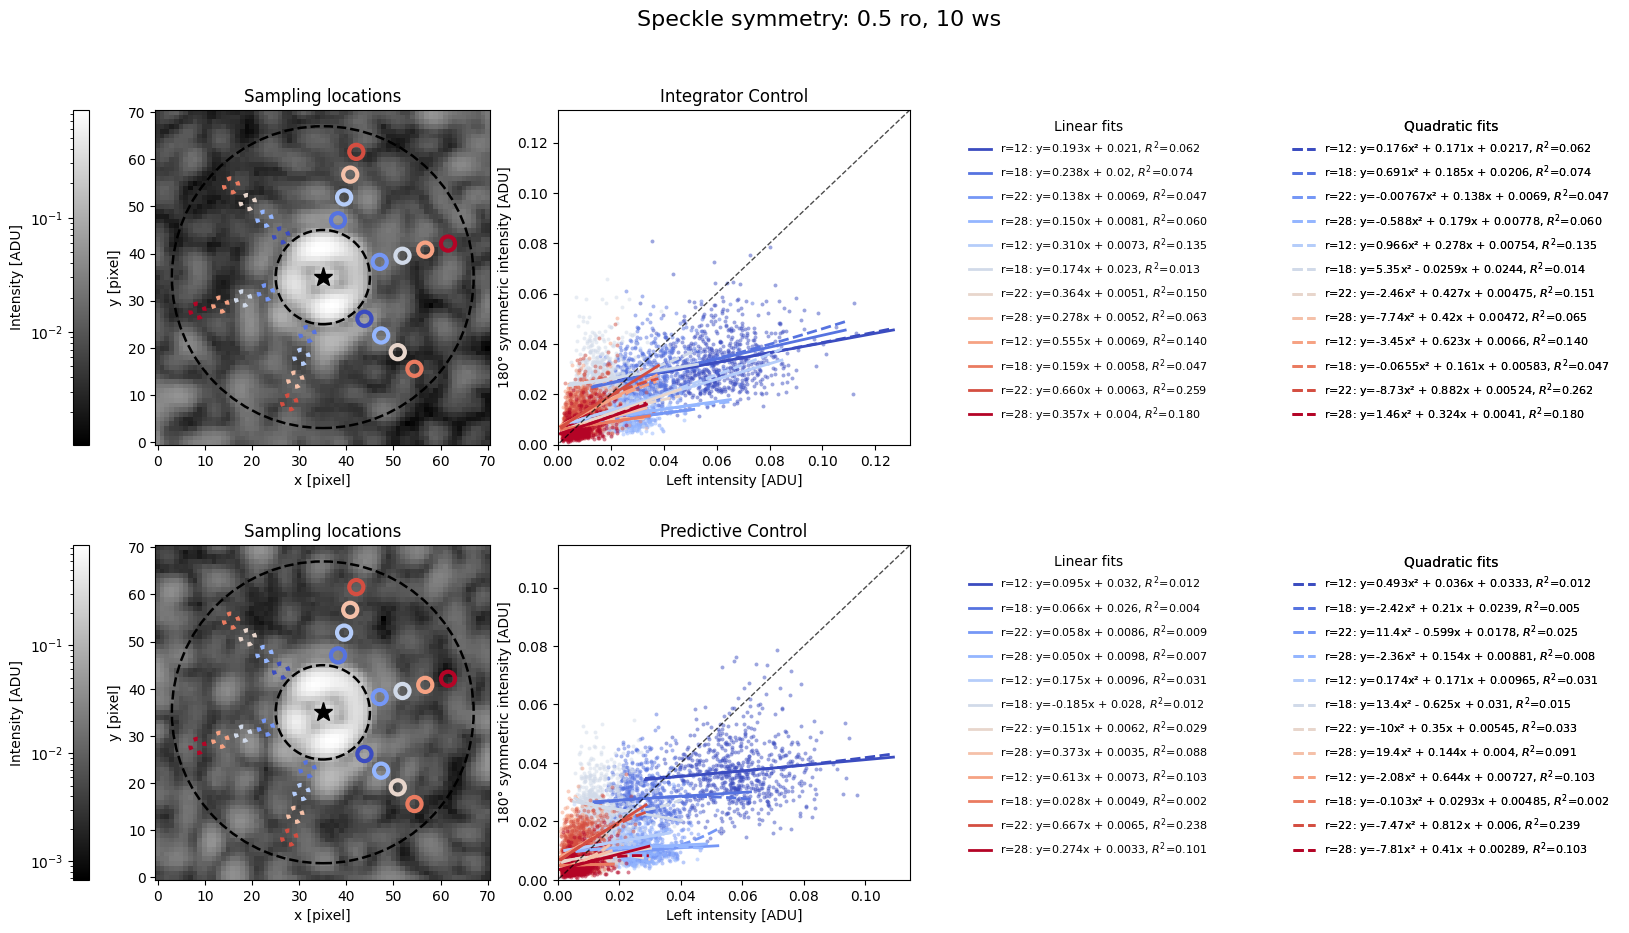

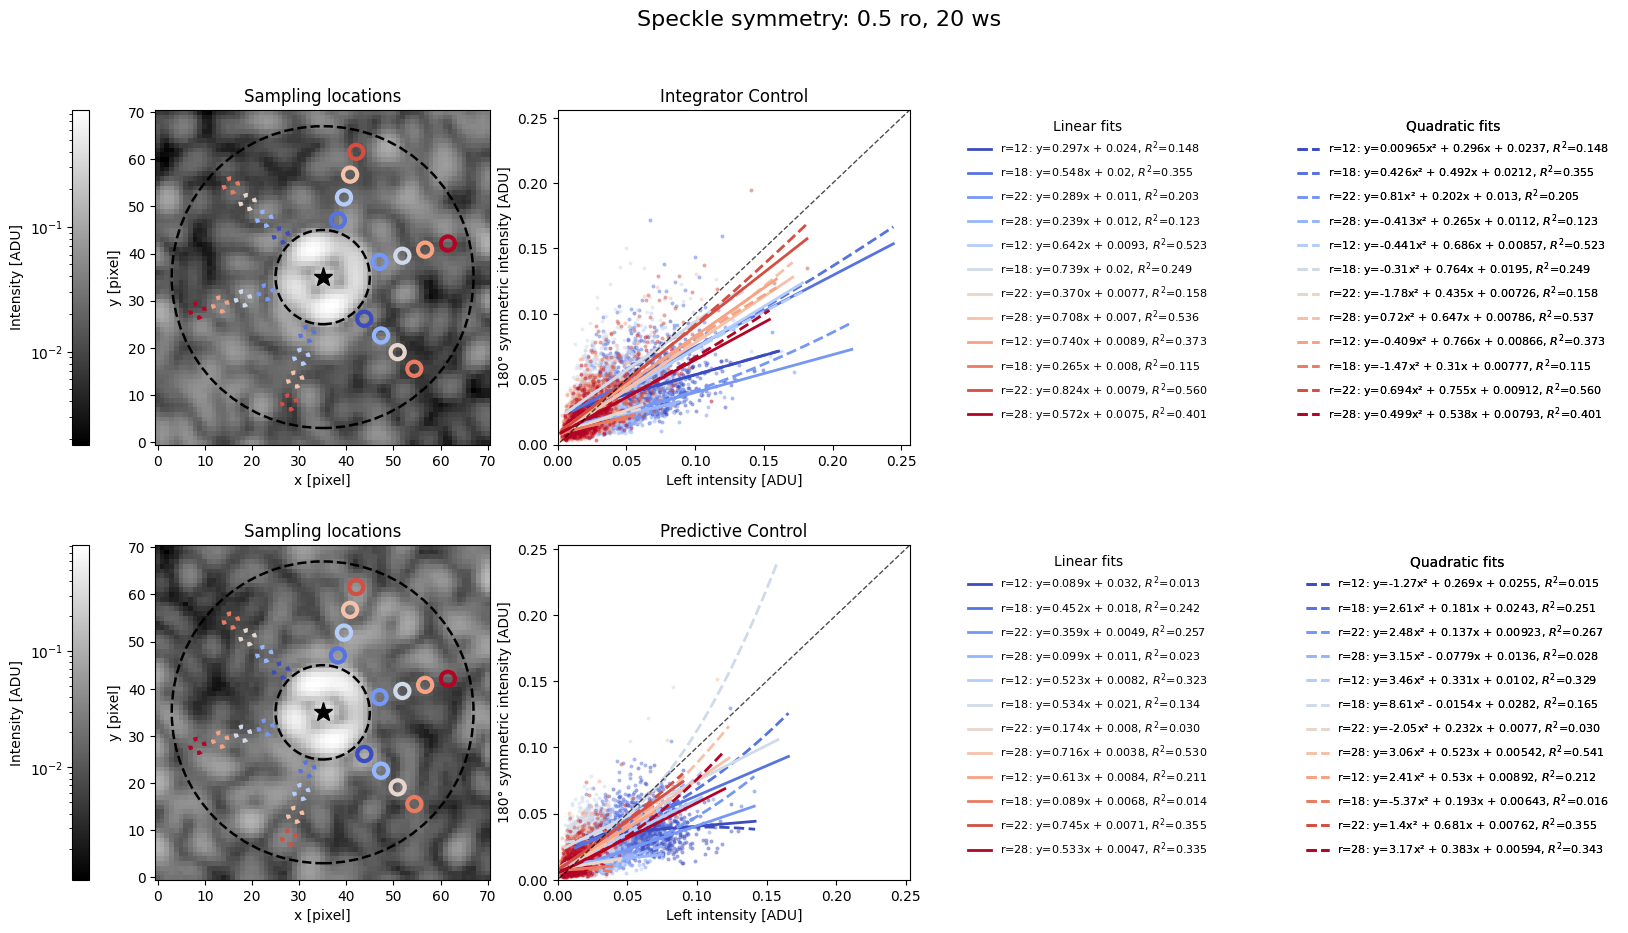

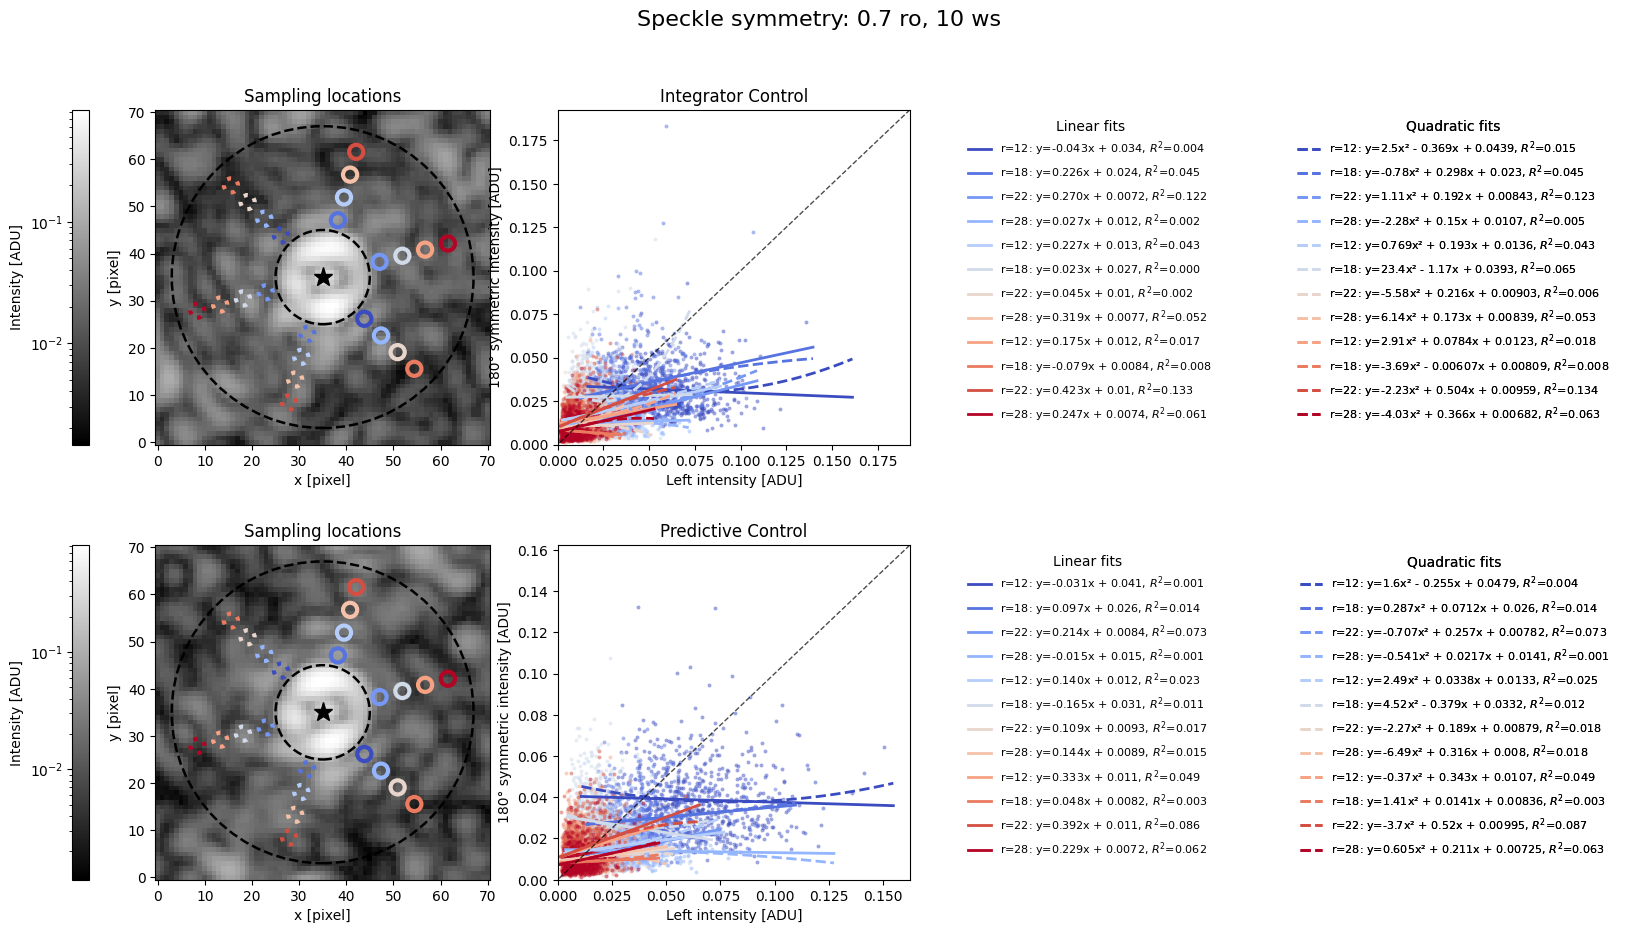

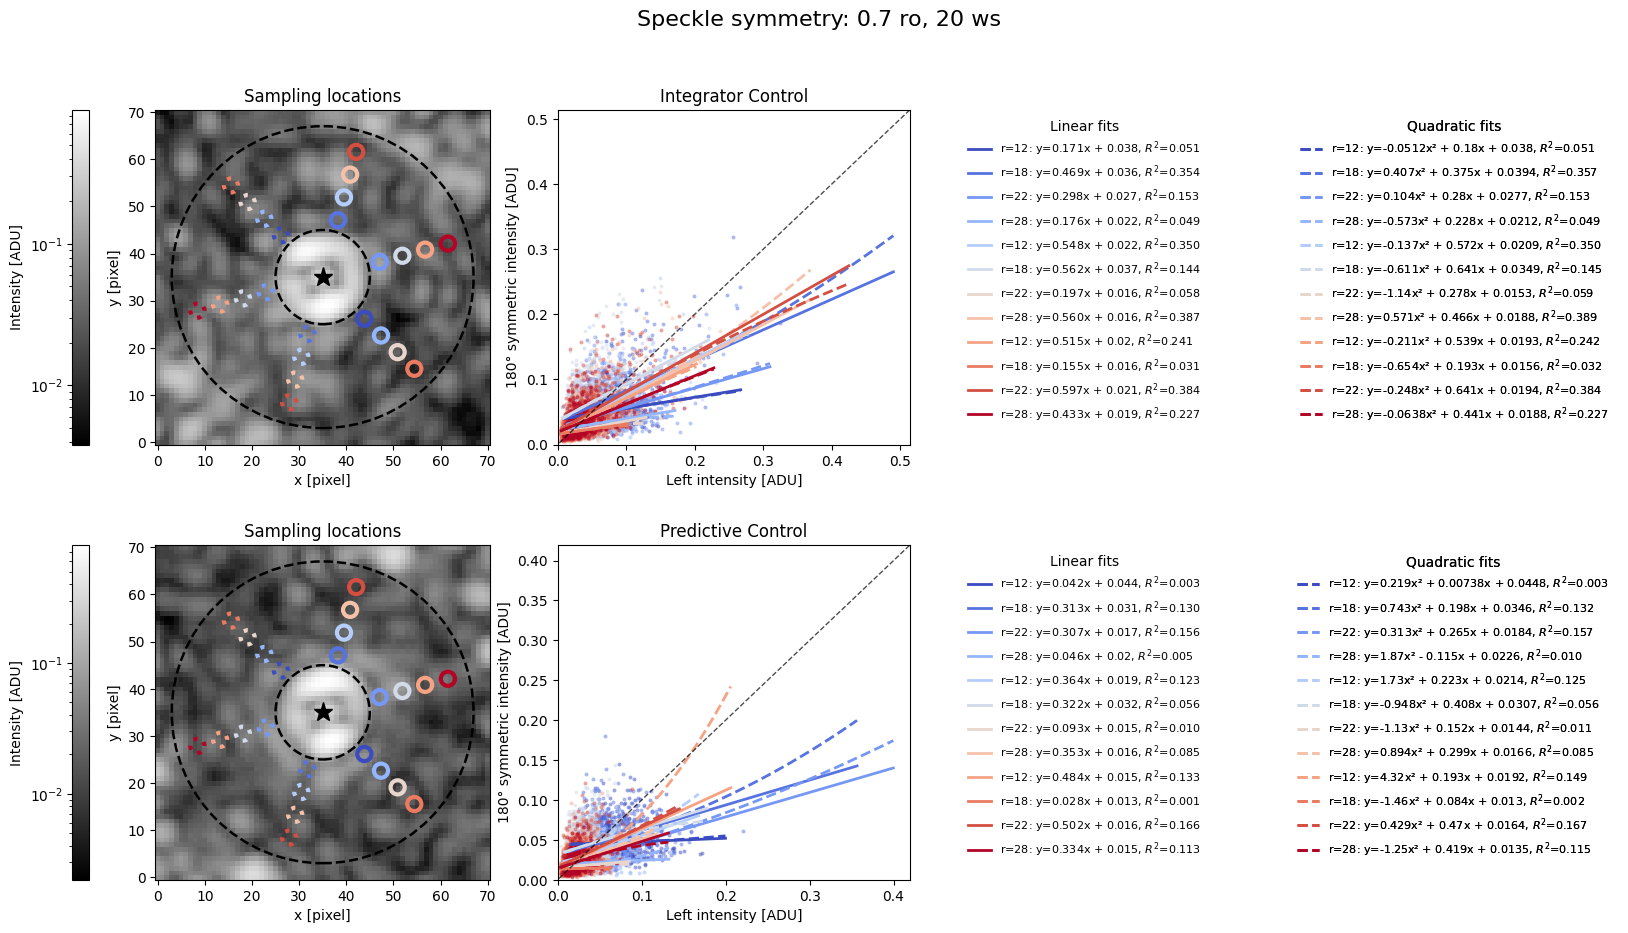

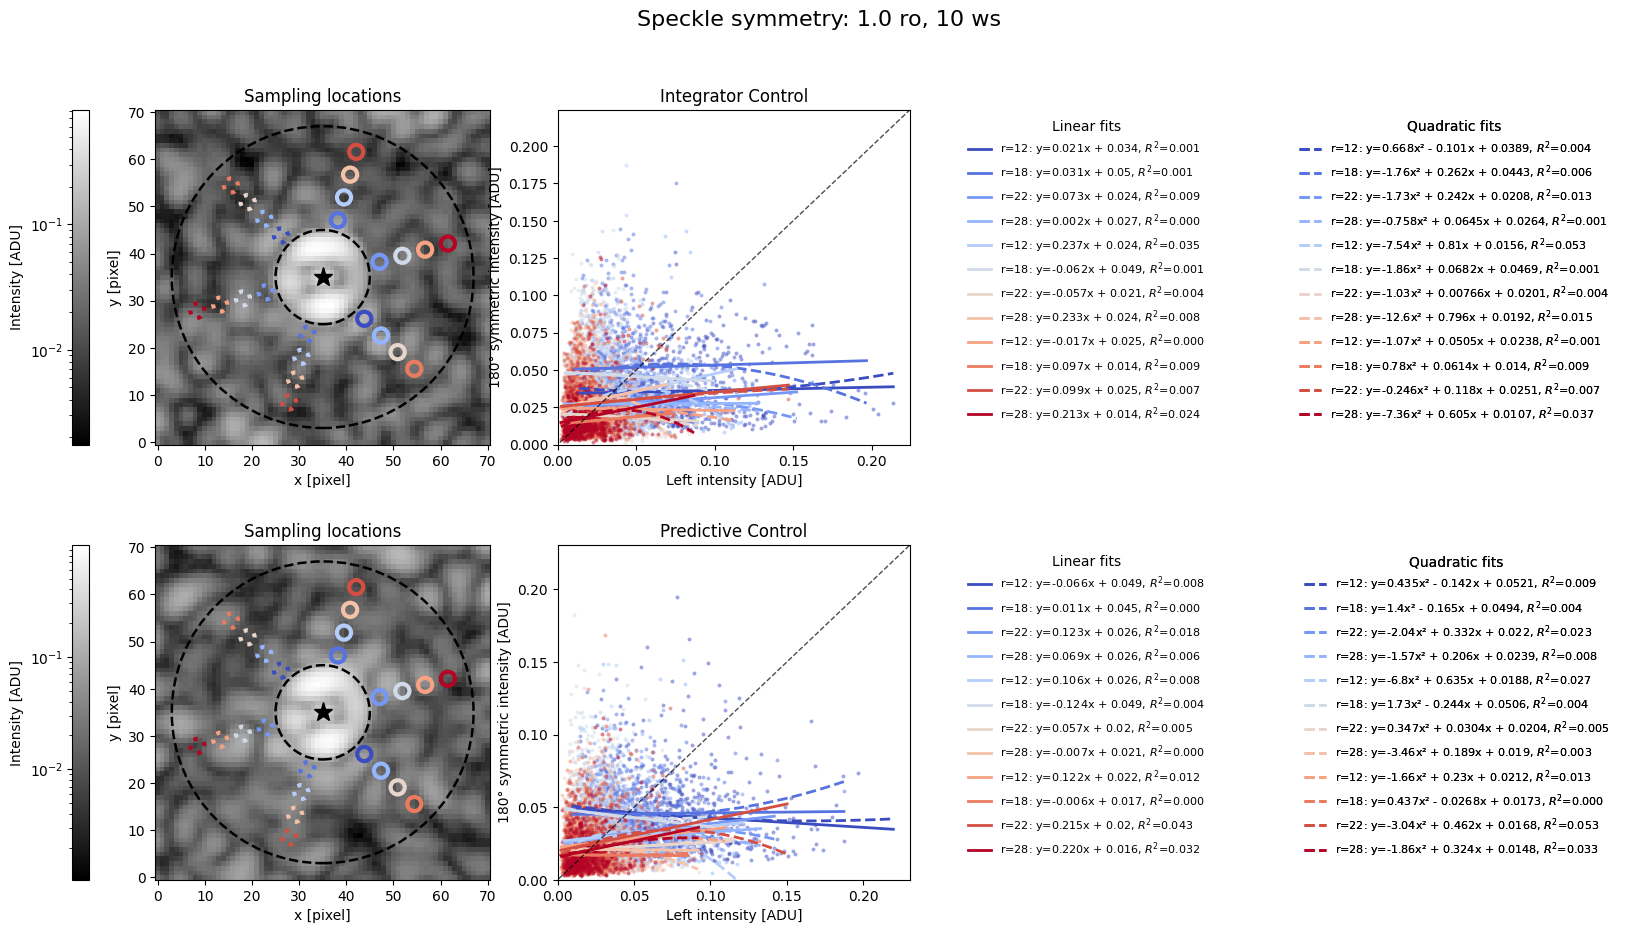

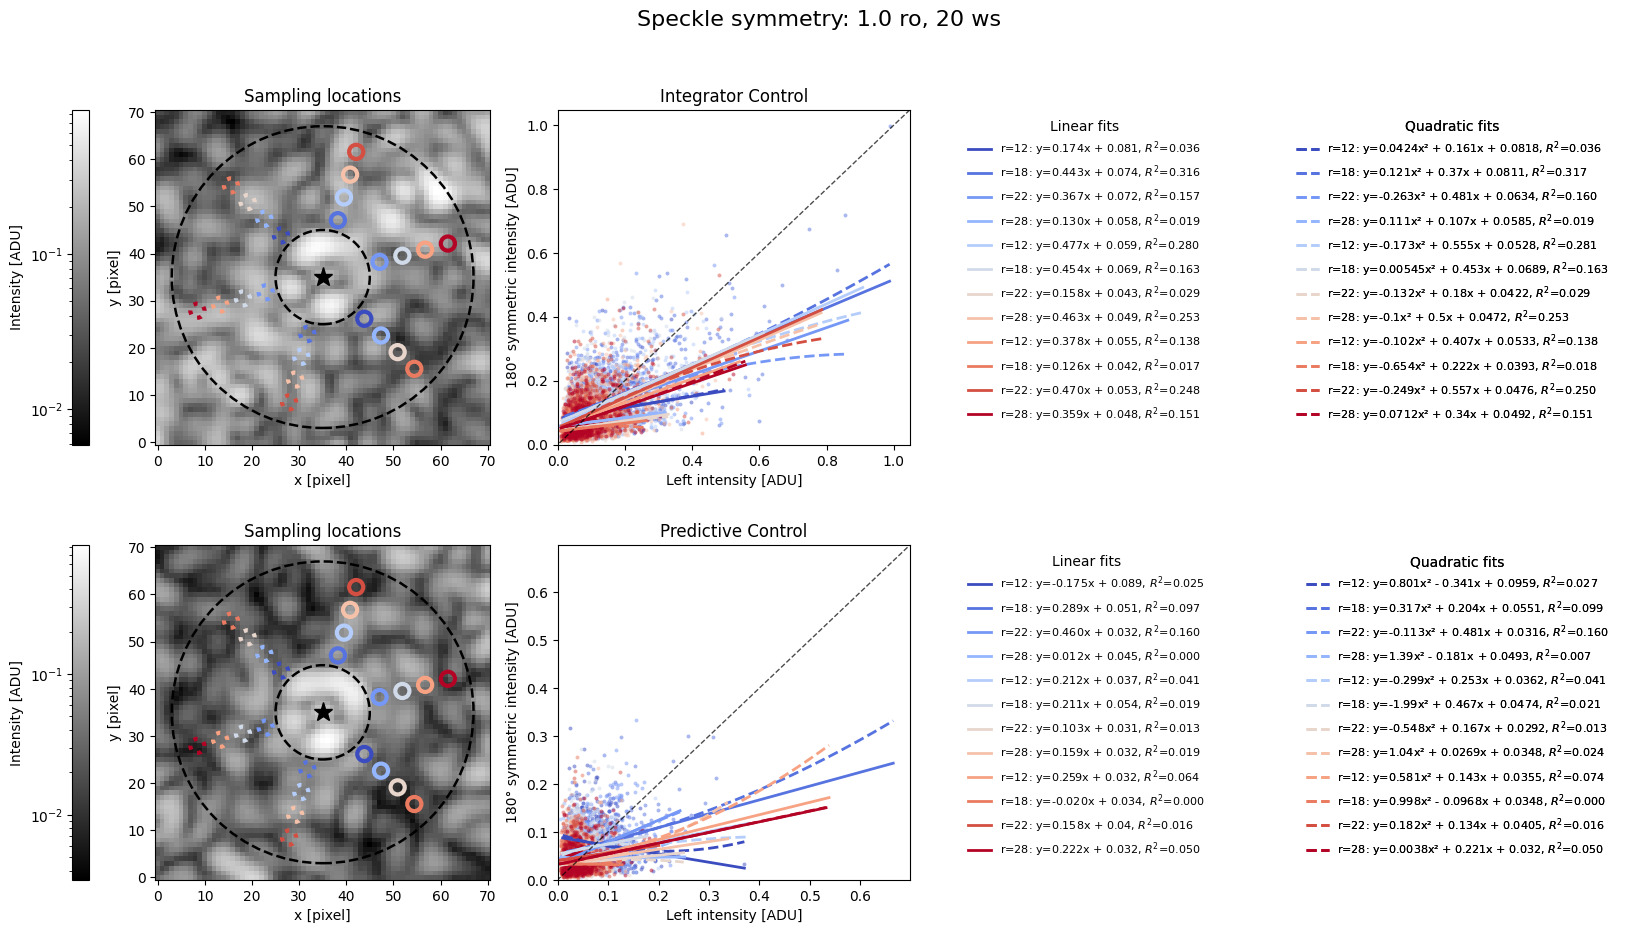

In [14]:
def symmetric_intensities(
    cube,
    angles_deg,
    r_min,
    r_max,
    dr=5.0,
):
# ============================================================
# Symmetric intensity function
# ============================================================

    """
    Extract intensities along a radial line and its 180-degree
    symmetric counterpart.

    Parameters
    ----------
    cube : ndarray
        Image cube with shape (n_frames, ny, nx).

    angle_deg : float or array-like
        Angle of the radial line in degrees.
        0 deg = +x direction
        90 deg = +y direction

    r_min : float
        Minimum radial distance from the center.

    r_max : float
        Maximum radial distance from the center.

    dr : float
        Radial separation between samples in pixels.

    Returns
    -------

    left : ndarray
        Intensities along the selected radial direction.
        Shape = (n_angles, n_frames, n_radii).

    symmetric : ndarray
        Intensities at the 180-degree symmetric positions.
        Shape = (n_angles, n_frames, n_radii).

    """

    n_frames, ny, nx = cube.shape

    # Make sure even a single angle becomes an array
    angles_deg = np.atleast_1d(angles_deg)
    angles_rad = np.deg2rad(angles_deg)

    # --------------------------------------------------------
    # Sub-pixel center
    # --------------------------------------------------------
    cy, cx = center_subpixel(cube[0])

    # --------------------------------------------------------
    # Radial coordinates
    # --------------------------------------------------------
    radii = np.arange(
        r_min + 0.5 * dr,
        r_max,
        dr
    )

    n_angles = len(angles_deg)
    n_radii = len(radii)

    # --------------------------------------------------------
    # Coordinates along selected direction
    # --------------------------------------------------------
    x1 = (cx + radii[None, :] * np.cos(angles_rad)[:, None]).T.flatten()
    y1 = (cy + radii[None, :] * np.sin(angles_rad)[:, None]).T.flatten()

    # --------------------------------------------------------
    # 180-degree symmetric coordinates
    # --------------------------------------------------------
    x2 = (cx - radii[None, :] * np.cos(angles_rad)[:, None]).T.flatten()
    y2 = (cy - radii[None, :] * np.sin(angles_rad)[:, None]).T.flatten()

    # --------------------------------------------------------
    # Storage
    # --------------------------------------------------------
    left = np.empty(
        (n_frames, n_radii * n_angles),
        dtype=cube.dtype
    )

    symmetric = np.empty_like(left)

    # --------------------------------------------------------
    # Extract intensities
    # --------------------------------------------------------
    for i in range(n_frames):

        left[i, :] = map_coordinates(
            cube[i],
            [y1, x1],
            order=1,
            mode="nearest"
        )

        symmetric[i, :] = map_coordinates(
            cube[i],
            [y2, x2],
            order=1,
            mode="nearest"
        )

    return (x1,y1), left, (x2,y2), symmetric

def plot_symmetric_intensities_single( 
        data_cube, ax_img, ax_int, title, angle=45.0, coro_rad=8, st2_rad=32, dr=5.0, crop=20, aperture_radius=1.5, ):
    """
    Plot the image and symmetric-intensity relation for one dataset.

    Parameters
    ----------
    data_cube : ndarray
        Intensity cube with shape (n_samples, ny, nx).

    ax_img : matplotlib.axes.Axes
        Axes object for the image plot.

    ax_int : matplotlib.axes.Axes
        Axes object for the intensity plot.

    title : str
        Title for the figure.

    angle : float
        Sampling angle in degrees.

    coro_rad : float
        Coronagraph radius in pixels.

    st2_rad : float
        Outer sampling radius in pixels.

    dr : float
        Radial sampling step in pixels.

    crop : int
        Number of pixels cropped from each image edge.

    aperture_radius : float
        Radius of the aperture markers in pixels.

    Returns
    -------
    fig, axes
        Matplotlib figure and axes.
    """

    # ========================================================
    # Extract symmetric intensities
    # ========================================================
    (
        (x1, y1),
        left_int,
        (x2, y2),
        symmetric_int,
    ) = symmetric_intensities(
        data_cube[:, crop:-crop, crop:-crop],
        angle,
        coro_rad,
        st2_rad,
        dr=dr,
    )

    # ========================================================
    # Radial positions
    # ========================================================
    radii = np.arange(
        coro_rad + 0.5 * dr,
        st2_rad,
        dr,
    )

    # ========================================================
    # COLORMAP
    # ========================================================
    # Colors are now based purely on the sample index,
    # NOT on radial distance.
    cmap = plt.get_cmap("coolwarm")

    size = len(radii) * len(angle) if isinstance(angle, list) else len(radii)
    colors = [
        cmap(i / max(size - 1, 1))
        for i in range(size)
    ]

    # ========================================================
    # IMAGE
    # ========================================================
    image = data_cube[
        0,
        crop:-crop,
        crop:-crop,
    ]

    cy, cx = center_subpixel(image)

    # --------------------------------------------------------
    # Image intensity normalization
    # --------------------------------------------------------
    # Ignore zero / negative values because LogNorm requires
    # strictly positive values.
    positive_image = image[image > 0]

    image_norm = LogNorm(
        vmin=positive_image.min(),
        vmax=positive_image.max(),
    )

    im = ax_img.imshow(
        image,
        origin="lower",
        cmap="gray",
        norm=image_norm,
    )

    # --------------------------------------------------------
    # Image colorbar
    # --------------------------------------------------------
    cbar_img = ax_img.figure.colorbar(
        im,
        ax=ax_img,
        fraction=0.046,
        pad=0.15,
        location="left",
    )

    cbar_img.set_label("Intensity [ADU]")

    # --------------------------------------------------------
    # Center = black star
    # --------------------------------------------------------
    ax_img.plot(
        cx,
        cy,
        marker="*",
        markersize=14,
        markerfacecolor="black",
        markeredgecolor="black",
        linestyle="None",
        zorder=20,
    )

    # --------------------------------------------------------
    # ST2 radius
    # --------------------------------------------------------
    ax_img.add_patch( Circle(
        (cx, cy),
        st2_rad,
        fill=False,
        edgecolor="black",
        linewidth=1.8,
        linestyle="--",
        zorder=10,
    ))

    # ax_img.add_patch(st2_circle)

    # --------------------------------------------------------
    # Coronagraph radius
    # --------------------------------------------------------
    ax_img.add_patch( Circle(
        (cx, cy),
        coro_rad,
        fill=False,
        edgecolor="black",
        linewidth=1.8,
        linestyle="--",
        zorder=10,
    ))

    # ax_img.add_patch(coro_circle)


    # ========================================================
    # APERTURES
    # ========================================================
    for j, (xx, yy) in enumerate(zip(x1, y1)):

        color = colors[j]

        # Selected side 
        ax_img.add_patch( Circle(
            (xx, yy),
            aperture_radius,
            fill=False,
            edgecolor=color,
            linewidth=3,
        ))

        # ax_img.add_patch(aperture)

        # Symmetric side
        ax_img.add_patch( Circle(
            (x2[j], y2[j]),
            aperture_radius,
            fill=False,
            edgecolor=color,
            linewidth=3.0,
            linestyle=":",
        ))

        # ax_img.add_patch(aperture_sym)

    ax_img.set_title(
        f"Sampling locations"
        #f"$\\theta={(ang for ang in angle if isinstance(angle, list) and angle is not None else angle):.1f}^\\circ$"
    )

    ax_img.set_xlabel("x [pixel]")
    ax_img.set_ylabel("y [pixel]")

    # ========================================================
    # SYMMETRIC INTENSITY GRAPH + LINEAR FIT
    # ========================================================
    
    fit_results = [] 
    linear_legend_handles = []
    quadratic_legend_handles = []
    for j in np.arange(size):
        r = radii[j % len(radii)]  # Use modulo to cycle through radii if angle is a list
        color = colors[j]
        x = np.asarray(left_int[:, j]) 
        y = np.asarray(symmetric_int[:, j])

        ax_int.scatter(
            x[::10],y[::10],
            color=color,
            s=8,
            alpha=0.5,
            linewidth=0,
        )

        # ---------------------------------------------------- 
        # # Remove invalid values before fitting 
        # # ---------------------------------------------------- 
        valid = ( np.isfinite(x) & np.isfinite(y) ) 
        x_fit = x[valid] 
        y_fit = y[valid]


        # --------------------------------------------------------
        # Linear and quadratic fits
        # --------------------------------------------------------
        
        if len(x_fit) >= 3:

            # ====================================================
            # LINEAR FIT
            # ====================================================

            linear_coeffs = np.polyfit(
                x_fit,
                y_fit,
                1,
            )

            slope, intercept = linear_coeffs

            y_pred_linear = np.polyval(
                linear_coeffs,
                x_fit,
            )

            ss_res_linear = np.sum(
                (y_fit - y_pred_linear) ** 2
            )

            ss_tot = np.sum(
                (y_fit - np.mean(y_fit)) ** 2
            )

            if ss_tot > 0:
                r_squared_linear = (
                    1
                    - ss_res_linear / ss_tot
                )
            else:
                r_squared_linear = np.nan

            # ====================================================
            # QUADRATIC FIT
            # ====================================================

            quadratic_coeffs = np.polyfit(
                x_fit,
                y_fit,
                2,
            )

            a, b, c = quadratic_coeffs

            y_pred_quadratic = np.polyval(
                quadratic_coeffs,
                x_fit,
            )

            ss_res_quadratic = np.sum(
                (y_fit - y_pred_quadratic) ** 2
            )

            if ss_tot > 0:
                r_squared_quadratic = (
                    1
                    - ss_res_quadratic / ss_tot
                )
            else:
                r_squared_quadratic = np.nan

            # ====================================================
            # PLOT BOTH FITS
            # ====================================================

            x_line = np.linspace(
                x_fit.min(),
                x_fit.max(),
                100,
            )

            # Linear
            y_line_linear = (
                slope * x_line
                + intercept
            )

            ax_int.plot(
                x_line,
                y_line_linear,
                color=color,
                linewidth=2,
                linestyle="-",
            )

            # Quadratic
            y_line_quadratic = (
                a * x_line**2
                + b * x_line
                + c
            )

            ax_int.plot(
                x_line,
                y_line_quadratic,
                color=color,
                linewidth=2,
                linestyle="--",
            )

        else:

            slope = np.nan
            intercept = np.nan
            r_squared_linear = np.nan

            a = np.nan
            b = np.nan
            c = np.nan
            r_squared_quadratic = np.nan


        # --------------------------------------------------------
        # Store fit
        # --------------------------------------------------------

        fit_results.append(
            {
                "radius": r,

                # Linear
                "slope": slope,
                "intercept": intercept,
                "r_squared_linear": r_squared_linear,

                # Quadratic
                "a": a,
                "b": b,
                "c": c,
                "r_squared_quadratic": r_squared_quadratic,
            }
        )


        # --------------------------------------------------------
        # Legend entries
        # --------------------------------------------------------

        if np.isfinite(slope):

            # Linear
            sign_linear = (
                "+"
                if intercept >= 0
                else "-"
            )

            linear_label = (
                f"r={r:.0f}: "
                f"y={slope:.3f}x "
                f"{sign_linear} "
                f"{abs(intercept):.2g}, "
                f"$R^2$={r_squared_linear:.3f}"
            )

            # Quadratic
            sign_b = "+" if b >= 0 else "-"
            sign_c = "+" if c >= 0 else "-"

            quadratic_label = (
                f"r={r:.0f}: "
                f"y={a:.3g}x² "
                f"{sign_b} {abs(b):.3g}x "
                f"{sign_c} {abs(c):.3g}, "
                f"$R^2$={r_squared_quadratic:.3f}"
            )

        else:

            linear_label = (
                f"r={r:.0f}: fit unavailable"
            )

            quadratic_label = (
                f"r={r:.0f}: fit unavailable"
            )


        # --------------------------------------------------------
        # Separate legend handles
        # --------------------------------------------------------

        linear_legend_handles.append(
            Line2D(
                [0],
                [0],
                color=color,
                linewidth=2,
                linestyle="-",
                label=linear_label,
            )
        )

        quadratic_legend_handles.append(
            Line2D(
                [0],
                [0],
                color=color,
                linewidth=2,
                linestyle="--",
                label=quadratic_label,
            )
        )

    #legend_handles.append( Line2D( [0], [0], color=color, linewidth=2, label=label, ) )
    
    ax_int.set_title(title)

    ax_int.set_xlabel("Left intensity [ADU]")
    ax_int.set_ylabel("180° symmetric intensity [ADU]")

    # --------------------------------------------------------
    # y = x reference line
    # --------------------------------------------------------
    xlim = ax_int.get_xlim()
    ylim = ax_int.get_ylim()

    lo = min(xlim[0], ylim[0])
    hi = max(xlim[1], ylim[1])

    ax_int.plot(
        [lo, hi],
        [lo, hi],
        color="black",
        linestyle="--",
        linewidth=1,
        alpha=0.7,
    )

    ax_int.set_xlim(0, hi)
    ax_int.set_ylim(0, hi)



    # ========================================================
    # Legend
    # ========================================================

    # ax_int.legend(
    #     handles=legend_handles,
    #     title="Linear fits",
    #     loc="best",
    #     fontsize=10,
    # )

    return linear_legend_handles, quadratic_legend_handles, fit_results


# ============================================================ 
# # COMPARISON FUNCTION 
# # ============================================================ 
# 
def plot_symmetric_comparison( int_cube, pred_cube, suptitle, angle=45.0, coro_rad=10, st2_rad=32, dr=5.0, crop=20, aperture_radius=1.5, 
                              ): 
    """ 
    Plot Integrator Control and Predictive Control in one 2x2 figure. 
    
    Returns 
    ------- 
    fig : matplotlib.figure.Figure 
    axes : ndarray 2x2 array of axes. 
    fit_results : dict Linear-fit results for both datasets. 
    """ 
    # ======================================================== 
    # # Figure 
    # # ======================================================== 
    # 
    # fig, axes = plt.subplots( 2, 2, figsize=(15, 10), ) 

    fig = plt.figure(figsize=(20, 10))

    gs = fig.add_gridspec(
        2,
        3,
        width_ratios=[1., 0.8, 1.5],
        wspace=0.1,
        hspace=0.3,
    )

    ax_img_int = fig.add_subplot(gs[0, 0])
    ax_int = fig.add_subplot(gs[0, 1])
    ax_legend_int = fig.add_subplot(gs[0, 2])

    ax_img_pred = fig.add_subplot(gs[1, 0])
    ax_pred = fig.add_subplot(gs[1, 1])
    ax_legend_pred = fig.add_subplot(gs[1, 2])

    # ======================================================== 
    # # Integrator Control 
    # # ======================================================== 
    linear_legend_handles, quadratic_legend_handles, fit_int = plot_symmetric_intensities_single( 
            int_cube, ax_img_int, ax_int, 
            title="Integrator Control", 
            angle=angle, coro_rad=coro_rad, st2_rad=st2_rad, dr=dr, crop=crop, 
            aperture_radius=aperture_radius, 
            ) 

    ax_legend_int.axis("off")

    legend_linear = ax_legend_int.legend(
        handles=linear_legend_handles,
        title="Linear fits",
        loc="upper left",
        fontsize=8,
        frameon=False,
    )

    legend_quadratic = ax_legend_int.legend(
        handles=quadratic_legend_handles,
        title="Quadratic fits",
        loc="upper right",
        fontsize=8,
        frameon=False,
    )

    ax_legend_int.add_artist(legend_linear)
    ax_legend_int.add_artist(legend_quadratic)
    # ======================================================== 
    # # Predictive Control 
    # # ======================================================== 
    linear_legend_handles_pred, quadratic_legend_handles_pred, fit_pred = plot_symmetric_intensities_single( 
            pred_cube, ax_img_pred, ax_pred, 
            title="Predictive Control", angle=angle, coro_rad=coro_rad, st2_rad=st2_rad, dr=dr, 
            crop=crop, aperture_radius=aperture_radius, )

    ax_legend_pred.axis("off")


    
    legend_linear_pred = ax_legend_pred.legend(
        handles=linear_legend_handles_pred,
        title="Linear fits",
        loc="upper left",
        fontsize=8,
        frameon=False,
    )

    legend_quadratic_pred = ax_legend_pred.legend(
        handles=quadratic_legend_handles_pred,
        title="Quadratic fits",
        loc="upper right",
        fontsize=8,
        frameon=False,
    )

    ax_legend_pred.add_artist(legend_linear_pred)
    ax_legend_pred.add_artist(legend_quadratic_pred)
    # ========================================================
    # Suptitle
    # ========================================================
    fig.suptitle(
        suptitle,
        fontsize=16,
    )

    fig.tight_layout(
        #rect=[0, 0, 1, 0.96]
    )

    # return fig, axes
    return ( 
        fig, 
        #axes, 
        { 
            "integrator": fit_int, 
            "predictive": fit_pred, 
            }, 
            )



for ro in [0.5, 0.7, 1.0]: 
    for ws in [10, 20]: 
        name = f"{ro}ro_{ws}ws" 
        int_cube = np.load( f"/home/aosimul/noah/data/ghost_images/10_20ws/int_{name}.npy" ) 
        pred_cube = np.load( f"/home/aosimul/noah/data/ghost_images/10_20ws/pred_{name}.npy" ) 
        fig, fit_results = plot_symmetric_comparison( 
            int_cube, pred_cube, suptitle=f"Speckle symmetry: {ro} ro, {ws} ws", angle=[-45, 75.0, 15.0], ) 
        plt.show()